# Notebook 01 — Dataset Overview
**Feature 1.7 — EDA & Data Understanding | HitRadar Pro**

## Mục tiêu
- Kết nối database `hitradar` và liệt kê analytics views.
- Kiểm tra row count, sample records, và data quality metrics.
- Tóm tắt toàn bộ dataset Spotify/HitRadar trước khi EDA chi tiết.
- Ghi nhận các data quality warnings carry-forward từ Feature 1.5.

In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

password = os.environ.get("PGPASSWORD")
if not password:
    raise RuntimeError("PGPASSWORD is not set. Please set it before running this notebook.")

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công:', conn.dsn)

Kết nối thành công: user=postgres password=xxx dbname=hitradar host=localhost port=5432


## 1. Danh sách Analytics Views

In [2]:
df_views = pd.read_sql("""
    SELECT table_name AS view_name
    FROM information_schema.views
    WHERE table_schema = 'analytics'
    ORDER BY table_name
""", conn)
print(f'Tổng số views: {len(df_views)}')
df_views

Tổng số views: 10


,view_name
0,vw_audio_trends
1,vw_data_quality_report
2,vw_duration_trends
3,vw_explicit_by_decade
4,vw_genre_trends
5,vw_ml_training_dataset
6,vw_popularity_stats
7,vw_top_artists
8,vw_tracks_by_decade
9,vw_tracks_overview


## 2. Row Counts các view chính

In [3]:
views_to_count = [
    'analytics.vw_tracks_overview',
    'analytics.vw_tracks_by_decade',
    'analytics.vw_audio_trends',
    'analytics.vw_popularity_stats',
    'analytics.vw_top_artists',
    'analytics.vw_genre_trends',
    'analytics.vw_explicit_by_decade',
    'analytics.vw_duration_trends',
    'analytics.vw_data_quality_report',
    'analytics.vw_ml_training_dataset',
]

cur = conn.cursor()
counts = []
for v in views_to_count:
    cur.execute(f'SELECT COUNT(*) FROM {v}')
    counts.append({'view': v.split('.')[1], 'row_count': cur.fetchone()[0]})

df_counts = pd.DataFrame(counts)
df_counts['row_count'] = df_counts['row_count'].apply(lambda x: f'{x:,}')
df_counts

,view,row_count
0,vw_tracks_overview,"586,672"
1,vw_tracks_by_decade,12
2,vw_audio_trends,101
3,vw_popularity_stats,5
4,vw_top_artists,"81,776"
5,vw_genre_trends,"19,103"
6,vw_explicit_by_decade,12
7,vw_duration_trends,101
8,vw_data_quality_report,16
9,vw_ml_training_dataset,"586,672"


## 3. Tóm tắt Dataset

In [4]:
summary = pd.read_sql("""
    SELECT
        (SELECT COUNT(*) FROM analytics.vw_tracks_overview)           AS tong_tracks,
        (SELECT COUNT(*) FROM analytics.vw_top_artists)               AS artists_co_track,
        (SELECT COUNT(DISTINCT genre_id) FROM analytics.vw_genre_trends) AS so_genres,
        (SELECT COUNT(DISTINCT release_year) FROM analytics.vw_audio_trends) AS so_nam,
        (SELECT COUNT(DISTINCT decade) FROM analytics.vw_tracks_by_decade)   AS so_thap_ky
""", conn)

print('=== TÓM TẮT DATASET ===')
for col in summary.columns:
    print(f'  {col:25s}: {summary[col].values[0]:,}')

=== TÓM TẮT DATASET ===
  tong_tracks              : 586,672
  artists_co_track         : 81,776
  so_genres                : 4,672
  so_nam                   : 101
  so_thap_ky               : 12


## 4. Sample Records

In [5]:
print('--- vw_tracks_overview (5 records) ---')
df_sample = pd.read_sql("""
    SELECT track_id, name, popularity, duration_min,
           release_year, decade, danceability, energy, valence
    FROM analytics.vw_tracks_overview LIMIT 5
""", conn)
display(df_sample)

print('\n--- vw_ml_training_dataset (5 records) ---')
df_ml = pd.read_sql("""
    SELECT track_id, target_popularity, duration_min,
           release_year, decade, danceability, energy, valence
    FROM analytics.vw_ml_training_dataset LIMIT 5
""", conn)
df_ml

--- vw_tracks_overview (5 records) ---


,track_id,name,popularity,duration_min,release_year,decade,danceability,energy,valence
0,2lyaLEbGPn7i1paCfnuFZz,I Say I' Sto Ccà - Remastered 2008,45,4.1502,1980,1980,0.882,0.493,0.746
1,26Kw6zBo3Uy98q5LTlFfVJ,Watching The Wheels - Remastered 2010,45,3.9989,1980,1980,0.607,0.612,0.272
2,36HznXQNGoen7dwq4Vv6nP,Twenty Four Hours - 2007 Remaster,45,4.4669,1980,1980,0.363,0.879,0.647
3,0ijdFzcMMkyr5FP73daA0Q,Drivin' My Life Away,45,3.2700,1980,1980,0.571,0.570,0.814
4,0zXG4lsgN27yAHYE2i8e87,瞳はダイアモンド,45,4.3000,1980,1980,0.545,0.399,0.332



--- vw_ml_training_dataset (5 records) ---


,track_id,target_popularity,duration_min,release_year,decade,danceability,energy,valence
0,2lyaLEbGPn7i1paCfnuFZz,45,4.1502,1980,1980,0.882,0.493,0.746
1,26Kw6zBo3Uy98q5LTlFfVJ,45,3.9989,1980,1980,0.607,0.612,0.272
2,36HznXQNGoen7dwq4Vv6nP,45,4.4669,1980,1980,0.363,0.879,0.647
3,0ijdFzcMMkyr5FP73daA0Q,45,3.2700,1980,1980,0.571,0.570,0.814
4,0zXG4lsgN27yAHYE2i8e87,45,4.3000,1980,1980,0.545,0.399,0.332


In [6]:
print('--- vw_data_quality_report ---')
pd.read_sql('SELECT * FROM analytics.vw_data_quality_report ORDER BY severity DESC, metric_name', conn)

--- vw_data_quality_report ---


,metric_name,metric_value,severity,note
0,artist_relations_diff,1,WARNING,"ON CONFLICT collapsed 1 duplicate (artist_id, ..."
1,data_quality_status,PASS_WITH_WARNINGS,WARNING,Feature 1.5 overall gate result — G05 duration...
2,duration_long_count,83,WARNING,Tracks with duration_ms > 3600000 ms — kept pe...
3,duration_short_count,26,WARNING,Tracks with duration_ms < 10000 ms — kept per ...
4,loudness_positive_count,219,WARNING,Tracks with loudness > 0 dB — unusual but valid
5,track_artists_coverage_pct,96.54,WARNING,730946 / 757170 — F1.4 cleaning log baseline
6,track_artists_skipped,26224,WARNING,Artist FK not found in artists.csv — F1.4 clea...
7,genre_join_coverage_pct,100.00,PASS,305595 / 305595 — F1.5 gate G09
8,artists_followers_null_count,11,INFO,clean.artists.followers IS NULL — retained by ...
9,clean_artist_genres_row_count,468680,INFO,From clean.artist_genres


## 5. Biểu đồ phân bổ theo decade

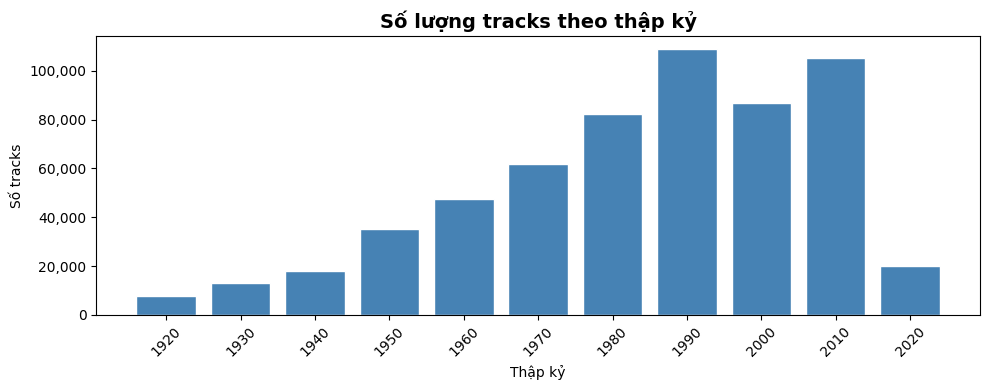

Thập kỷ nhiều tracks nhất: 1990s (108,875 tracks)


In [7]:
df_decade = pd.read_sql("""
    SELECT decade, track_count
    FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_decade['decade'].astype(str), df_decade['track_count'],
              color='steelblue', edgecolor='white')
ax.set_title('Số lượng tracks theo thập kỷ', fontsize=14, fontweight='bold')
ax.set_xlabel('Thập kỷ')
ax.set_ylabel('Số tracks')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f'Thập kỷ nhiều tracks nhất: {df_decade.loc[df_decade.track_count.idxmax(), "decade"]}s '
      f'({df_decade.track_count.max():,} tracks)')

## 6. Data Quality Warnings Carry-Forward

Các cảnh báo sau được ghi nhận từ Feature 1.5 và cần theo dõi trong EDA:

| Warning | Giá trị | Ghi chú |
|---------|---------|--------|
| Duration short (< 10s) | **26 tracks** | Giữ lại theo rule F1.4 |
| Duration long (> 60 min) | **83 tracks** | Giữ lại theo rule F1.4 |
| Loudness > 0 dB | **219 tracks** | Hiếm nhưng hợp lệ |
| track_artists coverage | **96.54%** (skipped 26,224) | Skipped = artist_id không có trong artists.csv |
| artist_relations diff | **1** | ON CONFLICT duplicate pair |
| tracks.name NULL | **71** | Retained by rule |
| artists.followers NULL | **11** | Retained by rule |

## 7. Kết luận

- Dataset gồm **586,672 tracks** từ nhiều thời kỳ (1900–2021), tập trung nhất ở thập kỷ 1990s (108,875) và 2010s (105,245).
- **81,776 artists** có ít nhất 1 track; **4,672 genres** được map qua `artist_genres`.
- Data quality: **PASS_WITH_WARNINGS** — không có lỗi cấu trúc, chỉ có warning về duration outliers và loudness.
- Dataset **đủ điều kiện cho EDA chi tiết** và ML handoff ở Feature 1.8.
- ⚠️ **Nhớ:** `target_popularity` là label ML, KHÔNG dùng làm input feature.

In [8]:
conn.close()
print('Done — Notebook 01 hoàn thành.')

Done — Notebook 01 hoàn thành.
